# Statistical Model Comparison (ARIMA vs VAR)

In [2]:
# 1. Import libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [3]:
# 2. Download data

data = yf.download(['KO', 'PEP'], start='2005-01-01', auto_adjust=False)

# Keep only closing prices
close_prices = data['Close'][['KO', 'PEP']].dropna()

print("Dataset shape:", close_prices.shape)
close_prices.tail()


[*********************100%***********************]  2 of 2 completed

Dataset shape: (5356, 2)


Ticker,KO,PEP
Date,,
2026-04-13,76.410004,155.880005
2026-04-14,75.900002,155.720001
2026-04-15,75.309998,154.850006
2026-04-16,75.180000,158.380005
2026-04-17,75.739998,157.669998


In [4]:
# Train-test split for ARIMA on price data

train_price = close_prices.iloc[:-10]
test_price = close_prices.iloc[-10:]

print("ARIMA training shape:", train_price.shape)
print("ARIMA test shape    :", test_price.shape)
print("\nTest dates:")
print(test_price.index)


ARIMA training shape: (5346, 2)
ARIMA test shape    : (10, 2)

Test dates:
DatetimeIndex(['2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09',
               '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15',
               '2026-04-16', '2026-04-17'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [5]:
# ARIMA model selection and forecasting

# KO
auto_model_ko = auto_arima(
    train_price['KO'],
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
ko_order = auto_model_ko.order

ko_model = ARIMA(train_price['KO'], order=ko_order)
ko_model_fit = ko_model.fit()
ko_forecast = ko_model_fit.forecast(steps=10)
ko_forecast = pd.Series(ko_forecast.values, index=test_price.index, name='KO_ARIMA_Forecast')

# PEP
auto_model_pep = auto_arima(
    train_price['PEP'],
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
pep_order = auto_model_pep.order

pep_model = ARIMA(train_price['PEP'], order=pep_order)
pep_model_fit = pep_model.fit()
pep_forecast = pep_model_fit.forecast(steps=10)
pep_forecast = pd.Series(pep_forecast.values, index=test_price.index, name='PEP_ARIMA_Forecast')

print("Best ARIMA order for KO :", ko_order)
print("Best ARIMA order for PEP:", pep_order)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=7622.572, Time=5.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=7626.674, Time=1.31 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7623.084, Time=0.42 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7623.225, Time=0.98 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=7627.077, Time=0.31 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=7625.963, Time=5.73 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=7626.049, Time=4.99 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=7603.205, Time=12.03 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=7622.348, Time=6.42 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=7595.377, Time=10.67 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=7593.410, Time=6.19 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=7608.940, Time=1.40 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=7595.390, Time=8.14 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=7624.817, Time=1.08 sec
 ARIMA(5,1,0)(0,0,0)[0] interce

C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=17831.466, Time=7.40 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=17949.380, Time=0.22 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=17881.464, Time=0.63 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=17885.372, Time=0.73 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=17948.609, Time=0.19 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=17881.929, Time=2.68 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=17882.115, Time=3.92 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=17831.661, Time=8.19 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=17831.588, Time=14.22 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=17880.459, Time=2.01 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=17879.609, Time=4.28 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=17881.728, Time=3.84 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=17831.970, Time=16.22 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=17830.882, Time=2.84 sec
 ARIMA(1,1,2)(0,0

C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Best ARIMA order for KO : (4, 1, 1)
Best ARIMA order for PEP: (2, 1, 2)


C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [6]:
# ARIMA metrics

def mape(actual, forecast):
    return np.mean(np.abs((actual - forecast) / actual)) * 100

arima_results = pd.DataFrame({
    'Stock': ['KO', 'PEP'],
    'Model': ['ARIMA', 'ARIMA'],
    'RMSE': [
        np.sqrt(mean_squared_error(test_price['KO'], ko_forecast)),
        np.sqrt(mean_squared_error(test_price['PEP'], pep_forecast))
    ],
    'MAE': [
        mean_absolute_error(test_price['KO'], ko_forecast),
        mean_absolute_error(test_price['PEP'], pep_forecast)
    ],
    'MAPE (%)': [
        mape(test_price['KO'], ko_forecast),
        mape(test_price['PEP'], pep_forecast)
    ],
    'Order / Lag': [str(ko_order), str(pep_order)]
})

arima_results


,Stock,Model,RMSE,MAE,MAPE (%),Order / Lag
0,KO,ARIMA,1.000637,0.910359,1.192804,"(4, 1, 1)"
1,PEP,ARIMA,1.688156,1.319246,0.850009,"(2, 1, 2)"


In [7]:
# Prepare differenced data for VAR

diff_data = close_prices.diff().dropna()

train_var = diff_data.iloc[:-10]
test_var = diff_data.iloc[-10:]

print("VAR training shape:", train_var.shape)
print("VAR test shape    :", test_var.shape)


VAR training shape: (5345, 2)
VAR test shape    : (10, 2)


In [8]:
# VAR lag selection and forecasting

var_base_model = VAR(train_var)
lag_results = var_base_model.select_order(maxlags=15)
print(lag_results.summary())

lag_order = lag_results.aic
print("\nSelected VAR lag order by AIC:", lag_order)

var_model = var_base_model.fit(lag_order)

forecast_input = train_var.values[-lag_order:]
forecast = var_model.forecast(y=forecast_input, steps=10)
forecast_df = pd.DataFrame(forecast, index=test_var.index, columns=['KO', 'PEP'])

# Convert differenced forecasts back to price level
last_values = close_prices.iloc[-11]
forecast_prices = forecast_df.cumsum() + last_values

forecast_prices.head()


C:\Users\engr_\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -1.535      -1.533      0.2154      -1.534
1       -1.548     -1.541*      0.2127     -1.545*
2       -1.549      -1.536      0.2125      -1.544
3       -1.548      -1.531      0.2127      -1.542
4       -1.551      -1.529      0.2120      -1.543
5       -1.552      -1.525      0.2118      -1.542
6       -1.554      -1.522      0.2115      -1.542
7       -1.557      -1.519      0.2109      -1.544
8       -1.556      -1.514      0.2110      -1.541
9       -1.559      -1.512      0.2103      -1.543
10      -1.560      -1.508      0.2101      -1.542
11      -1.559      -1.502      0.2103      -1.539
12      -1.560      -1.498      0.2101      -1.539
13     -1.561*      -1.494     0.2100*      -1.537
14      -1.560      -1.489      0.2100      -1.535
15      -1.560      -1.484      0.2101      -1.533
-------------------------------

,KO,PEP
Date,,
2026-04-06,76.826818,157.202356
2026-04-07,76.891670,157.160751
2026-04-08,76.880510,157.311140
2026-04-09,76.901317,157.327381
2026-04-10,76.976537,157.518228


In [9]:
# VAR metrics

actual = close_prices.iloc[-10:]

var_results = pd.DataFrame({
    'Stock': ['KO', 'PEP'],
    'Model': ['VAR', 'VAR'],
    'RMSE': [
        np.sqrt(mean_squared_error(actual['KO'], forecast_prices['KO'])),
        np.sqrt(mean_squared_error(actual['PEP'], forecast_prices['PEP']))
    ],
    'MAE': [
        mean_absolute_error(actual['KO'], forecast_prices['KO']),
        mean_absolute_error(actual['PEP'], forecast_prices['PEP'])
    ],
    'MAPE (%)': [
        mape(actual['KO'], forecast_prices['KO']),
        mape(actual['PEP'], forecast_prices['PEP'])
    ],
    'Order / Lag': [str(lag_order), str(lag_order)]
})

var_results


,Stock,Model,RMSE,MAE,MAPE (%),Order / Lag
0,KO,VAR,1.128407,1.009262,1.325565,13
1,PEP,VAR,1.860295,1.442427,0.930494,13


In [10]:
# Combined metrics table

combined_metrics = pd.concat([arima_results, var_results], ignore_index=True)
combined_metrics


,Stock,Model,RMSE,MAE,MAPE (%),Order / Lag
0,KO,ARIMA,1.000637,0.910359,1.192804,"(4, 1, 1)"
1,PEP,ARIMA,1.688156,1.319246,0.850009,"(2, 1, 2)"
2,KO,VAR,1.128407,1.009262,1.325565,13
3,PEP,VAR,1.860295,1.442427,0.930494,13


In [11]:
# Combined comparison table for the 10-day test horizon

comparison_df = pd.DataFrame({
    'KO_Actual': actual['KO'],
    'KO_ARIMA_Forecast': ko_forecast,
    'KO_VAR_Forecast': forecast_prices['KO'],
    'PEP_Actual': actual['PEP'],
    'PEP_ARIMA_Forecast': pep_forecast,
    'PEP_VAR_Forecast': forecast_prices['PEP']
})

comparison_df


,KO_Actual,KO_ARIMA_Forecast,KO_VAR_Forecast,PEP_Actual,PEP_ARIMA_Forecast,PEP_VAR_Forecast
Date,,,,,,
2026-04-06,77.220001,76.758101,76.826818,156.729996,156.863851,157.202356
2026-04-07,75.910004,76.740525,76.891670,153.210007,156.996184,157.160751
2026-04-08,77.290001,76.745491,76.880510,154.800003,156.893662,157.311140
2026-04-09,78.180000,76.697462,76.901317,157.490005,156.958763,157.327381
2026-04-10,77.470001,76.729651,76.976537,157.059998,156.931285,157.518228
2026-04-13,76.410004,76.707934,77.026570,155.880005,156.926521,157.406483
2026-04-14,75.900002,76.723439,76.981457,155.720001,156.954752,157.395648
2026-04-15,75.309998,76.715453,76.991502,154.850006,156.913082,157.359118
2026-04-16,75.180000,76.719060,77.081803,158.380005,156.958699,157.546812


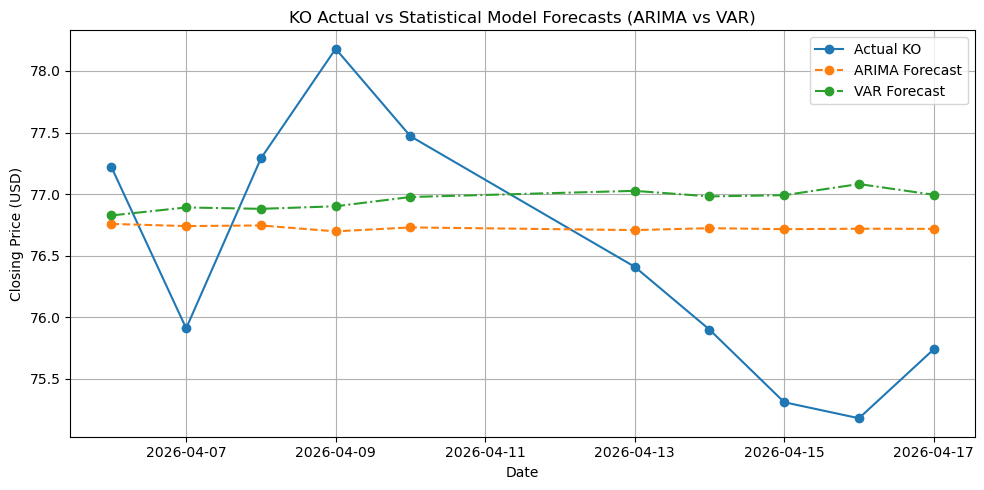

In [12]:
# Main report figure: KO actual vs ARIMA vs VAR

plt.figure(figsize=(10, 5))

plt.plot(actual.index, actual['KO'], marker='o', label='Actual KO')
plt.plot(actual.index, ko_forecast, marker='o', linestyle='--', label='ARIMA Forecast')
plt.plot(actual.index, forecast_prices['KO'], marker='o', linestyle='-.', label='VAR Forecast')

plt.title('KO Actual vs Statistical Model Forecasts (ARIMA vs VAR)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


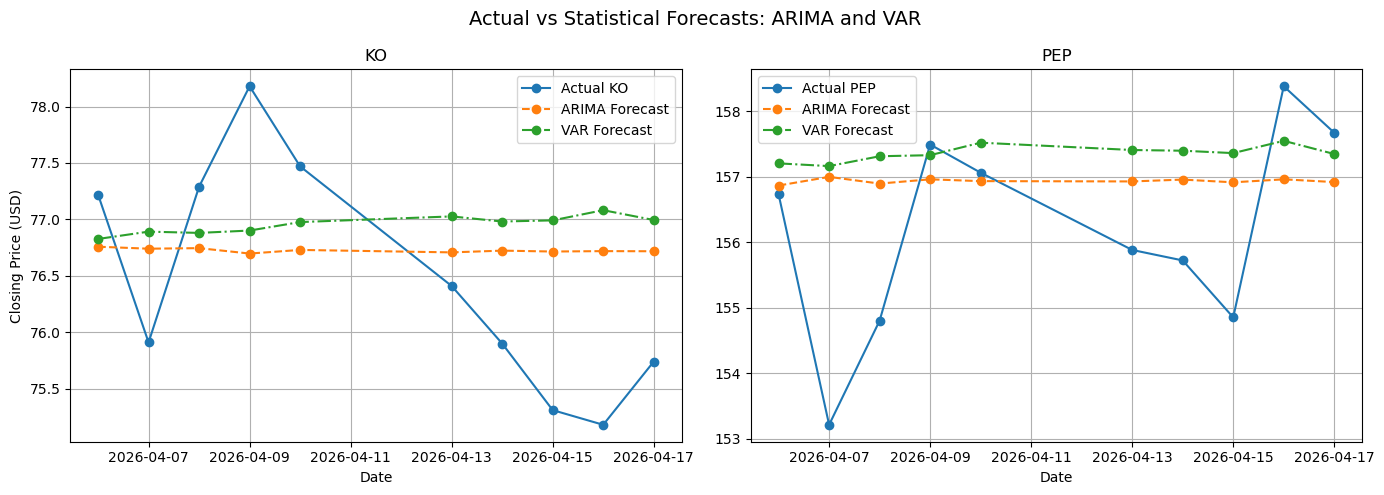

In [13]:
# Combined plot for KO and PEP

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# KO
axes[0].plot(actual.index, actual['KO'], marker='o', label='Actual KO')
axes[0].plot(actual.index, ko_forecast, marker='o', linestyle='--', label='ARIMA Forecast')
axes[0].plot(actual.index, forecast_prices['KO'], marker='o', linestyle='-.', label='VAR Forecast')
axes[0].set_title('KO')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Closing Price (USD)')
axes[0].grid(True)
axes[0].legend()

# PEP
axes[1].plot(actual.index, actual['PEP'], marker='o', label='Actual PEP')
axes[1].plot(actual.index, pep_forecast, marker='o', linestyle='--', label='ARIMA Forecast')
axes[1].plot(actual.index, forecast_prices['PEP'], marker='o', linestyle='-.', label='VAR Forecast')
axes[1].set_title('PEP')
axes[1].set_xlabel('Date')
axes[1].grid(True)
axes[1].legend()

plt.suptitle('Actual vs Statistical Forecasts: ARIMA and VAR', fontsize=14)
plt.tight_layout()
plt.show()


END